##### 1. Basic analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
prices = pd.read_csv('prices.csv', index_col='date', parse_dates=True)
prices.head()

,symbol,close,volume
date,,,
2010-01-04,AAPL,214.009998,123432400.0
2010-01-04,ABT,54.459951,10829000.0
2010-01-04,AIG,29.889999,7750900.0
2010-01-04,AMAT,14.300000,18615100.0
2010-01-04,ARNC,16.650013,11512100.0


- `close`	Closing Price:	The final price of the stock at the end of the trading day
- `volume`	Trading Volume:	The number of shares traded that day

<Axes: xlabel='date'>

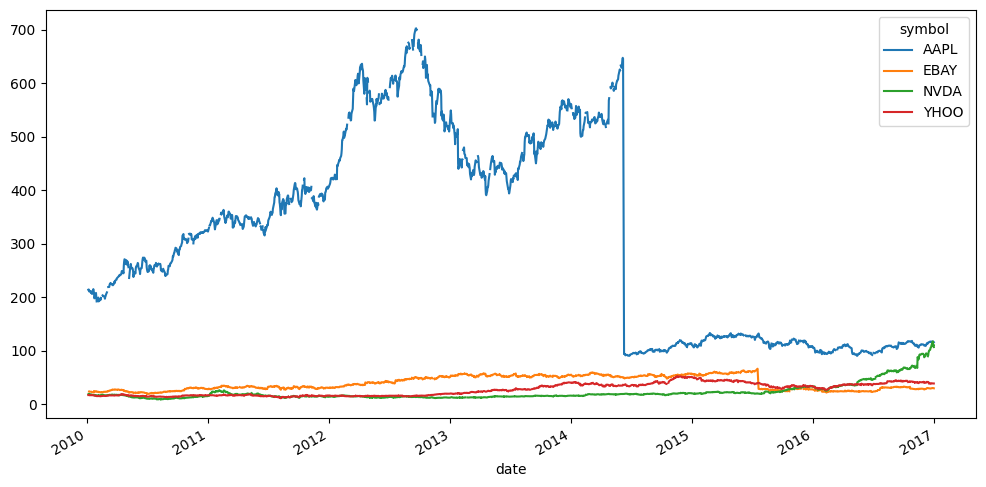

In [3]:
selected_symbols = ['AAPL', 'EBAY', 'NVDA', 'YHOO']
selected_data = prices[prices['symbol'].isin(selected_symbols)]

# Pivot the data so symbols become columns
pivot_prices = selected_data.pivot(columns='symbol', values='close')
 
pivot_prices.plot(figsize=(12, 6))

In [4]:
prices.isna().sum()

symbol       0
close     4245
volume       0
dtype: int64

##### 2. Feature engineer & Transforming

In [5]:
selected_data.head() # initial state

,symbol,close,volume
date,,,
2010-01-04,AAPL,214.009998,123432400.0
2010-01-04,EBAY,23.900000,22511600.0
2010-01-04,NVDA,18.490000,20005100.0
2010-01-04,YHOO,17.100000,16587400.0
2010-01-05,AAPL,214.379993,150476200.0


In [6]:
# pivot so symbols become columns
all_prices = selected_data.reset_index().pivot(index='date', columns='symbol', values='close')

all_prices.head() # present state

symbol,AAPL,EBAY,NVDA,YHOO
date,,,,
2010-01-04,214.009998,23.900000,18.490000,17.100000
2010-01-05,214.379993,NaN,18.760000,17.230000
2010-01-06,210.969995,23.500000,18.879999,17.170000
2010-01-07,210.580000,23.229998,NaN,16.700001
2010-01-08,211.980005,23.509999,18.549999,16.700001


- To fix missing values, we will use interpolation:

Missing values (close):
symbol
AAPL     87
EBAY    125
NVDA     77
YHOO     84
dtype: int64


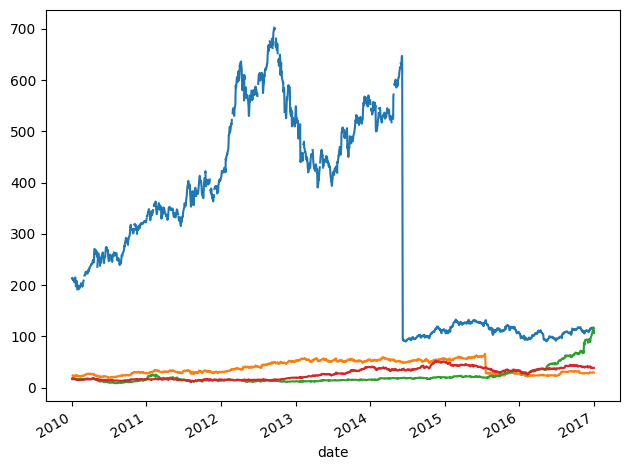

In [7]:
all_prices.plot(legend=False);
plt.tight_layout();

# Count the missing values of each time series
missing_values = all_prices.isnull().sum()
print("Missing values (close):")
print(missing_values)

In [8]:
def interpolate_and_plot(all_prices, interpolation):
    
    # Create a boolean mask for missing values
    missing_values = all_prices.isna()
    
    # Interpolate the missing values
    prices_interp = all_prices.interpolate(interpolation)
    
    # Plot the results, highlighting the interpolated values in black
    fig, ax = plt.subplots(figsize=(10, 5))
    prices_interp.plot(color='k', alpha=0.7, ax=ax, legend=False);
    
    # Note plot the interpolated values on top in blue
    prices_interp[missing_values].plot(ax=ax, color='b', lw=3, legend=False);
    plt.show()
    
    return prices_interp


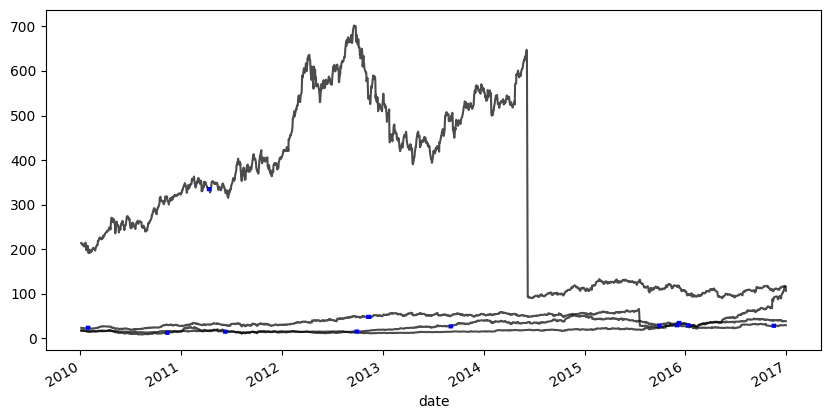

symbol,AAPL,EBAY,NVDA,YHOO
date,,,,
2010-01-04,214.009998,23.900000,18.490000,17.100000
2010-01-05,214.379993,23.900000,18.760000,17.230000
2010-01-06,210.969995,23.500000,18.879999,17.170000
2010-01-07,210.580000,23.229998,18.879999,16.700001
2010-01-08,211.980005,23.509999,18.549999,16.700001
...,...,...,...,...
2016-12-23,116.519997,29.790001,109.779999,38.660000
2016-12-27,117.260002,30.240000,117.320000,38.919998
2016-12-28,116.760002,30.010000,109.250000,38.730000


In [9]:
interpolation_type = 'zero'
interpolate_and_plot(all_prices, interpolation_type)

- interpolation_type of `zero`:

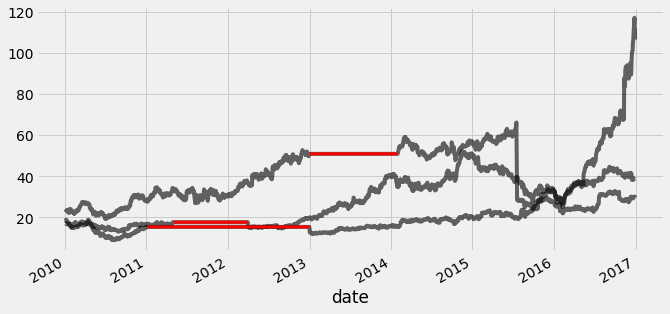

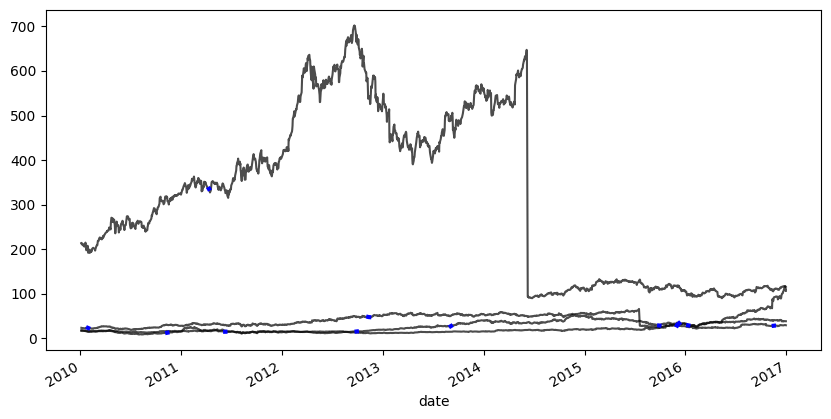

symbol,AAPL,EBAY,NVDA,YHOO
date,,,,
2010-01-04,214.009998,23.900000,18.490000,17.100000
2010-01-05,214.379993,23.700000,18.760000,17.230000
2010-01-06,210.969995,23.500000,18.879999,17.170000
2010-01-07,210.580000,23.229998,18.714999,16.700001
2010-01-08,211.980005,23.509999,18.549999,16.700001
...,...,...,...,...
2016-12-23,116.519997,29.790001,109.779999,38.660000
2016-12-27,117.260002,30.240000,117.320000,38.919998
2016-12-28,116.760002,30.010000,109.250000,38.730000


In [10]:
interpolation_type = 'linear'
interpolate_and_plot(all_prices, interpolation_type)

- interpolation_type of `linear`:

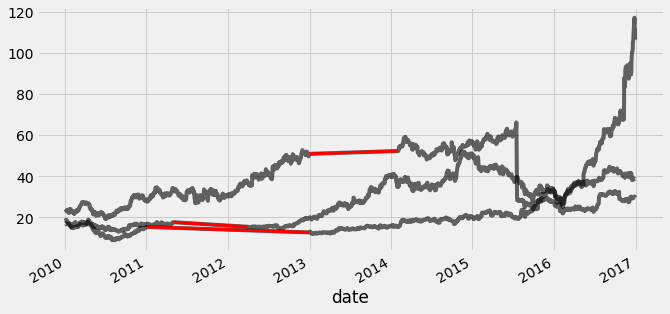

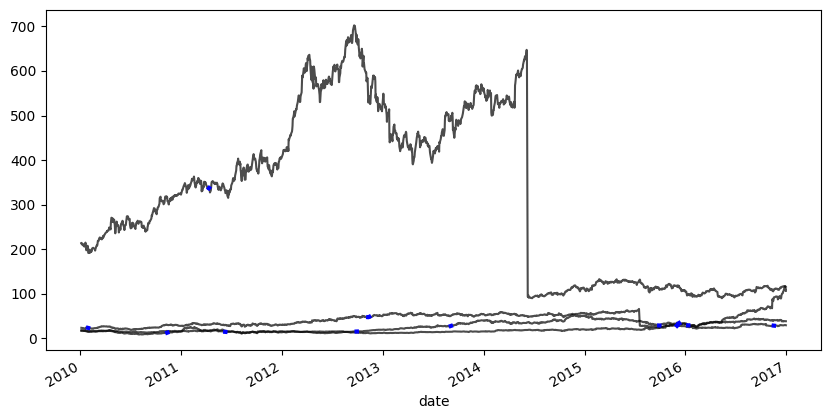

In [11]:
interpolation_type = 'quadratic'
df = interpolate_and_plot(all_prices, interpolation_type)

- interpolation_type of `quadratic`:

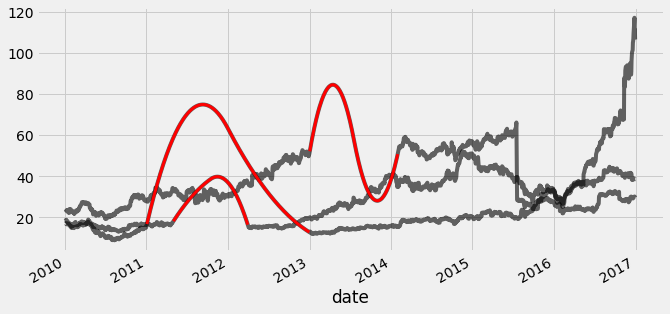

In [12]:
# check missing value after using `quadratic` interpolution:
df.isna().sum().sort_index()

symbol
AAPL    0
EBAY    0
NVDA    0
YHOO    0
dtype: int64

C:\Users\Zen7\AppData\Local\Temp\ipykernel_12676\1848815631.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_value = series[-1]  # last day (day 20)


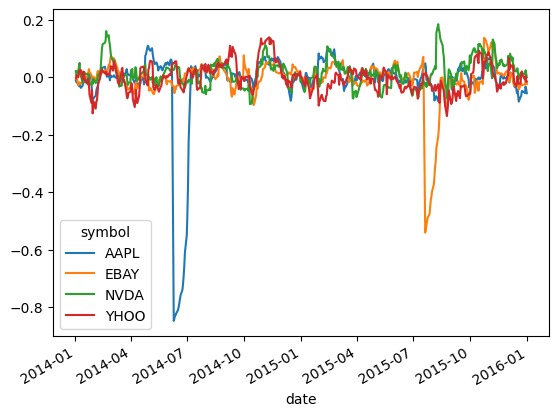

In [13]:
# Transforming
# Calculates the percentage change between the most recent price and the average price of the previous 20 days.
def percent_change(series):
    # Collect all *but* the last value of this window, then the final value
    previous_values = series[:-1] # first 19 days
    last_value = series[-1]  # last day (day 20)
    
    # Calculate the % difference between the last value and the average of previous 19 days (previous_values)
    percent_change = (last_value - np.mean(previous_values)) / np.mean(previous_values)
    return percent_change

# Apply your custom function and plot
prices_perc = df.rolling(20).apply(percent_change)
prices_perc.loc["2014":"2015"].plot();

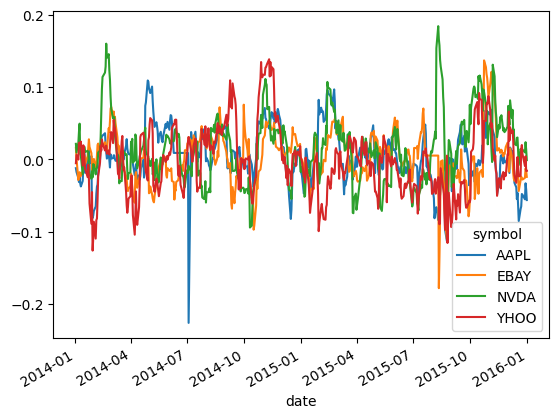

In [14]:
def replace_outliers(series):
    # Calculate the absolute difference of each timepoint from the series mean
    absolute_differences_from_mean = np.abs(series - np.mean(series))
    
    # Calculate a mask for the difference that are > 3 standard deviations from zero
    this_mask = absolute_differences_from_mean > (np.std(series) * 3)
    
    # Replace these values with the median across the data
    series[this_mask] = np.nanmedian(series)
    return series

# Apply your preprocessing functino to the timeseries and plot the results
prices_perc = prices_perc.apply(replace_outliers)
prices_perc.loc["2014":"2015"].plot();

C:\Users\Zen7\AppData\Local\Temp\ipykernel_12676\3209946322.py:7: FutureWarning: The provided callable <function min at 0x0000027E17B47920> is currently using Rolling.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  features = prices_perc_rolling.aggregate(features_to_calculate)
C:\Users\Zen7\AppData\Local\Temp\ipykernel_12676\3209946322.py:7: FutureWarning: The provided callable <function max at 0x0000027E17B477E0> is currently using Rolling.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  features = prices_perc_rolling.aggregate(features_to_calculate)
C:\Users\Zen7\AppData\Local\Temp\ipykernel_12676\3209946322.py:7: FutureWarning: The provided callable <function mean at 0x0000027E17B58220> is currently using Rolling.mean. In a future version of pandas, the provided callable will be used directly. To keep cu

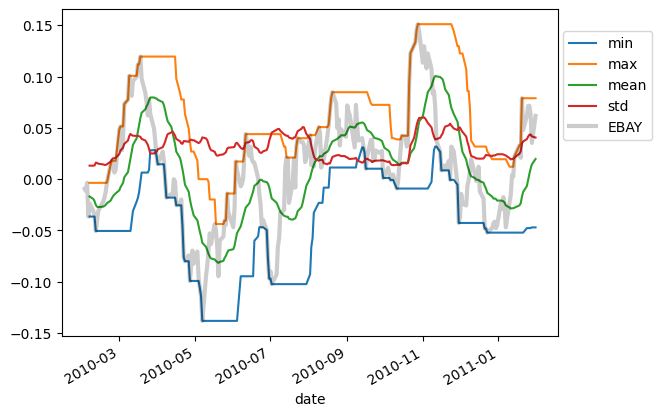

In [15]:
prices_perc_rolling = prices_perc['EBAY'].rolling(20, min_periods=5, closed='right')

# Define the features you'll calculate for each window
features_to_calculate = [np.min, np.max, np.mean, np.std]

# Calculate these features for your rolling window object
features = prices_perc_rolling.aggregate(features_to_calculate)

# Plot the results
ax = features.loc[:"2011-01"].plot();
prices_perc['EBAY'].loc[:"2011-01"].plot(ax=ax, color='k', alpha=0.2, lw=3);
ax.legend(loc=(1.01, 0.6));

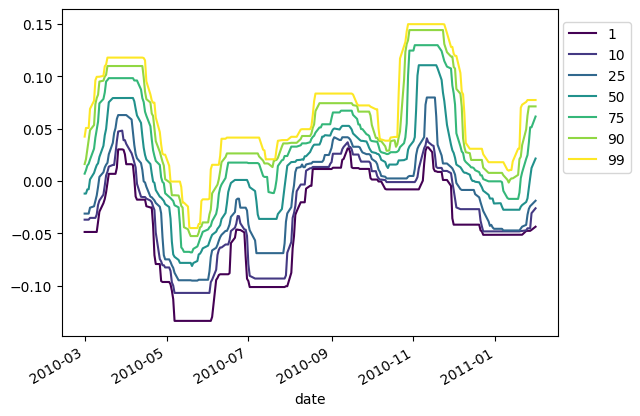

In [16]:
from functools import partial
percentiles = [1, 10, 25, 50, 75, 90, 99]

# Use a list comprehension to create a partial function for each quantile
percentile_functions = [partial(np.percentile, q=percentile) for percentile in percentiles]

# Calculate each of these quantiles on the data using a rolling window
prices_perc_rolling = prices_perc['EBAY'].rolling(20, min_periods=5, closed='right')
features_percentiles = prices_perc_rolling.aggregate(percentile_functions)

# Plot a subset of the result
ax = features_percentiles.loc[:"2011-01"].plot(cmap=plt.cm.viridis);
ax.legend(percentiles, loc=(1.01, 0.5));

In [18]:
prices_perc['day_of_week'] = prices_perc.index.dayofweek
prices_perc['month_of_year'] = prices_perc.index.month
prices_perc['quarter_of_year'] = prices_perc.index.quarter

# Print prices_perc
prices_perc

symbol,AAPL,EBAY,NVDA,YHOO,day_of_week,month_of_year,quarter_of_year
date,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,0,1,1
2010-01-05,NaN,NaN,NaN,NaN,1,1,1
2010-01-06,NaN,NaN,NaN,NaN,2,1,1
2010-01-07,NaN,NaN,NaN,NaN,3,1,1
2010-01-08,NaN,NaN,NaN,NaN,4,1,1
...,...,...,...,...,...,...,...
2016-12-23,0.028999,0.024842,0.147816,-0.037988,4,12,4
2016-12-27,0.033157,0.038030,0.008555,-0.027966,1,12,4
2016-12-28,0.025992,0.026925,0.117829,-0.029311,2,12,4


##### 2.1 Adding time-lag for better forecast accuracy

In [19]:
# Creates 10 new columns:
# lag_1_day = prices shifted by 1 day (yesterday's price)
# lag_2_day = prices shifted by 2 days (2 days ago)
# lag_3_day = prices shifted by 3 days
# ...
# lag_10_day = prices shifted by 10 days (10 days ago)

# Example:
# Original: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# lag_1_day: [NaN, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# lag_2_day: [NaN, NaN, 1, 2, 3, 4, 5, 6, 7, 8]

In [ ]:
# Step 1: Create the time lags [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
shifts = np.arange(1, 11).astype(int)

# Create lagged columns for EACH stock symbol
for symbol in ['AAPL', 'EBAY', 'NVDA', 'YHOO']:
    for day_shift in shifts: # for 0 in 'AAPL'
        col_name = f"{symbol}_lag_{day_shift}_day" # AAPL_lag_1_day
        prices_perc[col_name] = prices_perc[symbol].shift(day_shift) # data.shift(1) moves entire column down by 1

# Step 2: Drop rows with NaN (from lags and rolling window)
prices_perc = prices_perc.dropna()

print(f"Final dataset shape: {prices_perc.shape}")
prices_perc.head()

Final dataset shape: (1723, 47)
Columns: ['AAPL', 'EBAY', 'NVDA', 'YHOO', 'day_of_week', 'month_of_year', 'quarter_of_year', 'AAPL_lag_1_day', 'AAPL_lag_2_day', 'AAPL_lag_3_day', 'AAPL_lag_4_day', 'AAPL_lag_5_day', 'AAPL_lag_6_day', 'AAPL_lag_7_day', 'AAPL_lag_8_day', 'AAPL_lag_9_day', 'AAPL_lag_10_day', 'EBAY_lag_1_day', 'EBAY_lag_2_day', 'EBAY_lag_3_day', 'EBAY_lag_4_day', 'EBAY_lag_5_day', 'EBAY_lag_6_day', 'EBAY_lag_7_day', 'EBAY_lag_8_day', 'EBAY_lag_9_day', 'EBAY_lag_10_day', 'NVDA_lag_1_day', 'NVDA_lag_2_day', 'NVDA_lag_3_day', 'NVDA_lag_4_day', 'NVDA_lag_5_day', 'NVDA_lag_6_day', 'NVDA_lag_7_day', 'NVDA_lag_8_day', 'NVDA_lag_9_day', 'NVDA_lag_10_day', 'YHOO_lag_1_day', 'YHOO_lag_2_day', 'YHOO_lag_3_day', 'YHOO_lag_4_day', 'YHOO_lag_5_day', 'YHOO_lag_6_day', 'YHOO_lag_7_day', 'YHOO_lag_8_day', 'YHOO_lag_9_day', 'YHOO_lag_10_day']

First 5 rows of final dataset:


symbol,AAPL,EBAY,NVDA,YHOO,day_of_week,month_of_year,quarter_of_year,AAPL_lag_1_day,AAPL_lag_2_day,AAPL_lag_3_day,...,YHOO_lag_1_day,YHOO_lag_2_day,YHOO_lag_3_day,YHOO_lag_4_day,YHOO_lag_5_day,YHOO_lag_6_day,YHOO_lag_7_day,YHOO_lag_8_day,YHOO_lag_9_day,YHOO_lag_10_day
date,,,,,,,,,,,,,,,,,,,,,
2010-03-02,0.044483,0.051377,0.011220,0.027574,1,3,1,0.052025,0.033466,0.020969,...,0.034125,0.003727,-0.001552,0.020007,0.004158,0.010056,0.014879,0.009988,0.000273,-0.006211
2010-03-03,0.045432,0.028182,-0.001706,0.015168,2,3,1,0.044483,0.052025,0.033466,...,0.027574,0.034125,0.003727,-0.001552,0.020007,0.004158,0.010056,0.014879,0.009988,0.000273
2010-03-04,0.066524,0.039320,0.000885,0.030427,3,3,1,0.045432,0.044483,0.052025,...,0.015168,0.027574,0.034125,0.003727,-0.001552,0.020007,0.004158,0.010056,0.014879,0.009988
2010-03-05,0.084307,0.073187,0.029052,0.043856,4,3,1,0.066524,0.045432,0.044483,...,0.030427,0.015168,0.027574,0.034125,0.003727,-0.001552,0.020007,0.004158,0.010056,0.014879
2010-03-08,0.078349,0.077592,0.011039,0.070569,0,3,1,0.084307,0.066524,0.045432,...,0.043856,0.030427,0.015168,0.027574,0.034125,0.003727,-0.001552,0.020007,0.004158,0.010056


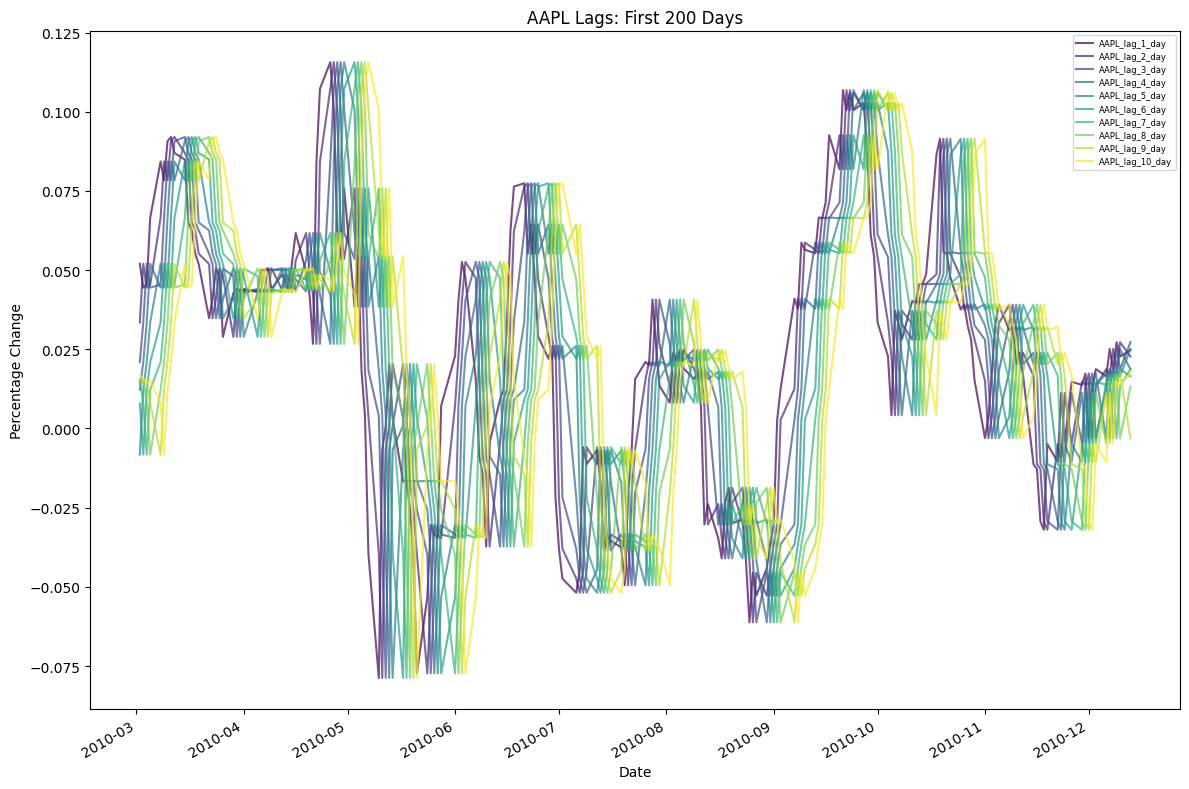

In [ ]:
# Plot heatmap of lags
fig, ax = plt.subplots(figsize=(12, 8))
aapl_lags = prices_perc.filter(like='AAPL_lag')
aapl_lags.iloc[:200].plot(ax=ax, alpha=0.7, cmap='viridis')
ax.set_title('AAPL Lags: First 200 Days')
ax.set_xlabel('Date')
ax.set_ylabel('Percentage Change')
ax.legend(loc='best', fontsize=6)
plt.tight_layout()
plt.show()

##### 3. Train and test using Ridge model

In [21]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

prices_perc = prices_perc.dropna() # drop 19 NaN

# Use stock symbols to extract training data
X = prices_perc.drop('AAPL', axis=1)  # All columns EXCEPT AAPL
y = prices_perc['AAPL']  # Target

# Fit and score the model with cross-validation
scores = cross_val_score(Ridge(), X, y, cv=3)
print(scores)

[0.75281771 0.67819149 0.79285267]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split our data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,
                                                   shuffle=False, random_state=1) # You do not want to shuffle time-series as test data from future might come into train data

# Fit our model and generate predictions
model = Ridge()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
score = r2_score(y_test, predictions)
print(score)

0.8073200434839466


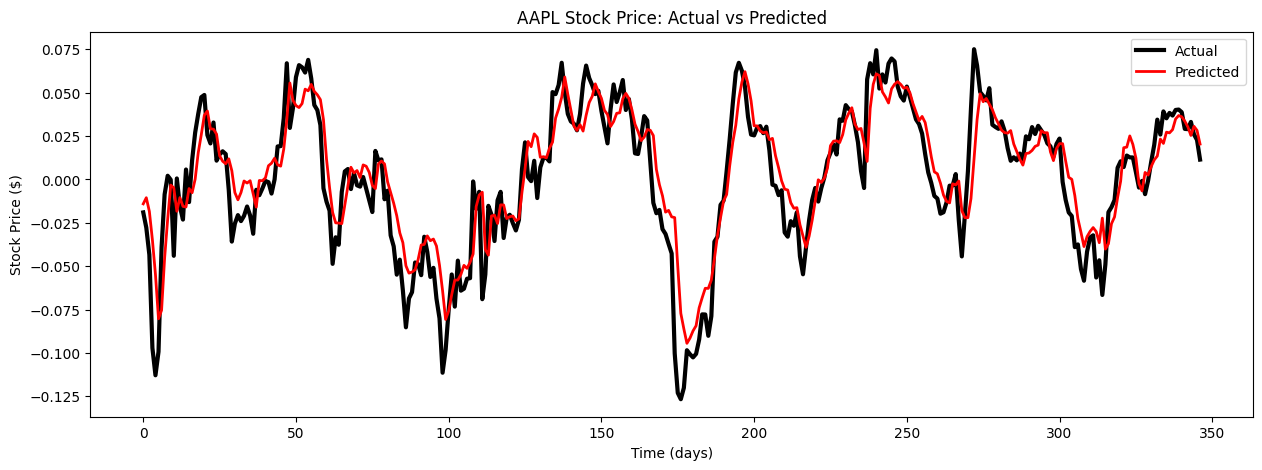

In [23]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(range(len(y_test)), y_test, color='k', lw=3, label='Actual')
ax.plot(range(len(predictions)), predictions, color='r', lw=2, label='Predicted')

ax.set_xlabel('Time (days)')  # x-axis label
ax.set_ylabel('Stock Price ($)')  # y-axis label
ax.set_title('AAPL Stock Price: Actual vs Predicted')
ax.legend()
plt.show()

In [ ]:
# # TimeSeriesSplit method
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import r2_score

# # Create time-series cross-validation object
# cv = TimeSeriesSplit(n_splits=10)

# results = []
# scores = []

# for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
#     # Split data
#     X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#     y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
#     # Train model
#     model = Ridge(alpha=1.0)
#     model.fit(X_train, y_train)
    
#     # Predict and score
#     predictions = model.predict(X_test)
#     score = r2_score(y_test, predictions)
#     scores.append(score)
    
#     # Store results
#     results.append((predictions, test_idx))
    
#     print(f"Fold {fold+1}: Train: {len(train_idx)} samples, Test: {len(test_idx)} samples, R²: {score:.4f}")

# print(f"\nAverage R²: {np.mean(scores):.4f}")
# print(f"Standard Deviation: {np.std(scores):.4f}")

# # Visualize predictions
# def visualize_predictions(results, y):
#     fig, axes = plt.subplots(2, 5, figsize=(15, 6))
#     axes = axes.ravel()
    
#     for i, (predictions, test_idx) in enumerate(results[:10]):
#         axes[i].plot(y.iloc[test_idx].values, color='k', lw=2, label='Actual')
#         axes[i].plot(predictions, color='r', lw=2, label='Predicted')
#         axes[i].set_title(f'Fold {i+1}')
#         axes[i].legend()
    
#     plt.tight_layout()
#     plt.show()

# visualize_predictions(results, y)

In [ ]:
# # ShuffleSplit method
# from sklearn.model_selection import ShuffleSplit
# from sklearn.metrics import r2_score
# from sklearn.linear_model import Ridge
# import numpy as np

# # Import ShuffleSplit and create the cross-validation object
# cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=1)

# # Iterate through CV splits
# results = []
# for tr, tt in cv.split(X, y):
#     # Fit the model on training data
#     model = Ridge()
#     model.fit(X.iloc[tr], y.iloc[tr])
    
#     # Generate predictions on the test data, score the predictions, and collect
#     prediction = model.predict(X.iloc[tt])
#     score = r2_score(y.iloc[tt], prediction)
#     results.append((prediction, score, tt))
    
#     print(f"Fold score: {score:.4f}")

# # Average score
# avg_score = np.mean([r[1] for r in results])
# print(f"Average R²: {avg_score:.4f}")

# # Custom function to quickly visualize predictions
# def visualize_predictions(results):
#     fig, axes = plt.subplots(2, 3, figsize=(15, 8))
#     axes = axes.ravel()
    
#     for i, (prediction, score, tt) in enumerate(results[:6]):
#         axes[i].plot(y.iloc[tt].values, color='k', lw=2, label='Actual')
#         axes[i].plot(prediction, color='r', lw=2, label='Predicted')
#         axes[i].set_title(f'Fold {i+1}: R² = {score:.3f}')
#         axes[i].legend()
    
#     plt.tight_layout()
#     plt.show()

# visualize_predictions(results)

- See which features affect prediction the most with coefficient

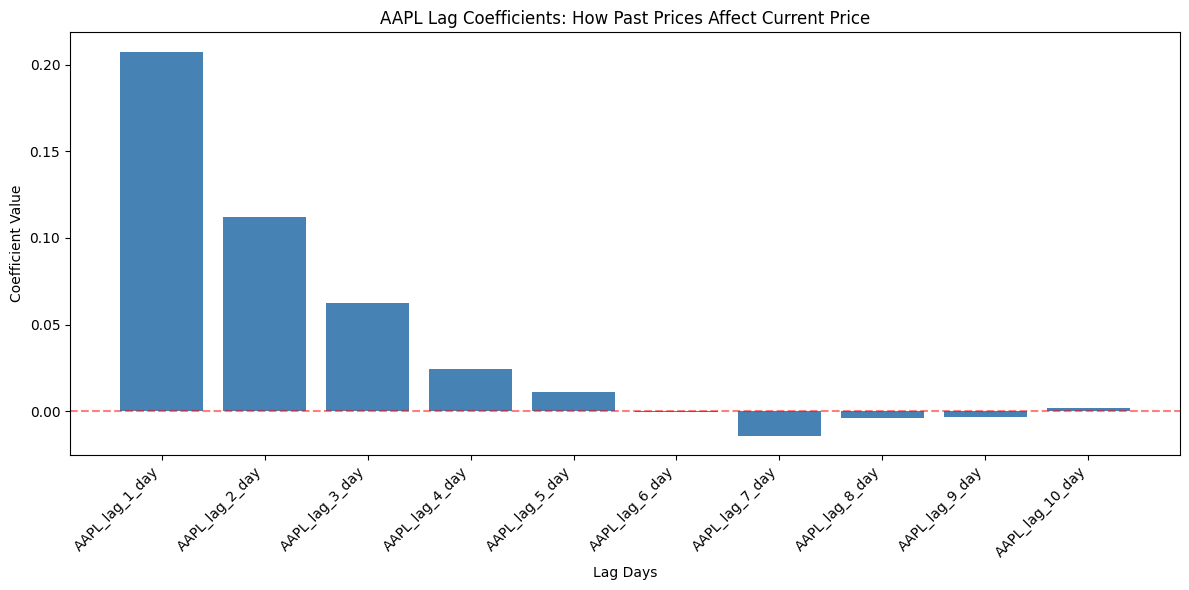


AAPL Lag Coefficients:
  Lag 1 day: 0.2075
  Lag 2 day: 0.1118
  Lag 3 day: 0.0628
  Lag 4 day: 0.0244
  Lag 5 day: 0.0114
  Lag 6 day: -0.0006
  Lag 7 day: -0.0141
  Lag 8 day: -0.0038
  Lag 9 day: -0.0030
  Lag 10 day: 0.0020


In [26]:
# Plot coefficients for AAPL lags
fig, ax = plt.subplots(figsize=(12, 6))

# Get coefficients for AAPL lag columns
aapl_lag_cols = [col for col in prices_perc.columns if 'AAPL_lag' in col]
aapl_lag_coefs = [model.coef_[i] for i, col in enumerate(prices_perc.columns) if 'AAPL_lag' in col]

# Create bar plot
ax.bar(aapl_lag_cols, aapl_lag_coefs, color='steelblue')
ax.set_xlabel('Lag Days')
ax.set_ylabel('Coefficient Value')
ax.set_title('AAPL Lag Coefficients: How Past Prices Affect Current Price')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print coefficients in order
print("\nAAPL Lag Coefficients:")
for col, coef in zip(aapl_lag_cols, aapl_lag_coefs):
    lag_num = col.split('_')[2]  # Extract the number from 'AAPL_lag_X_day'
    print(f"  Lag {lag_num} day: {coef:.4f}")